# Significance Testing

Demonstration of on/off counting in `heap.significance`: how the reflected region method and the ring background method pick the off regions and
count events, for wobble and on-source pointings, at the source and at other test positions.

We use toy events (`heap.toy_events`) so we know exactly where the source and the pointings are.

The region plots show each run in the sky map's frame (deg from `MAP_CENTER`), with east left and north up as on the sky, so a
test position is at the same place in every panel and each run's counts and camera move with its wobble:
- grey: that run's event counts; dashed: that run's camera edge
- magenta circle: on region
- blue circles: off regions; dotted grey: off regions not entirely inside the camera, not used
- `+`: the run's pointing
- star: the source

## Imports

In [20]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
from astropy.coordinates import SkyCoord

from heap import significance as sg
from heap import toy_events as toy
from heap.parameterize import CAMERA_EXTENT, CAMERA_HALF_WIDTH
from heap.sources import SOURCES

## Toy Data

In [21]:
THETA = 0.2 # on/off region radius (deg)
WOBBLE = 0.5 # wobble offset (deg): wobble N/S at Dec +/-30'
SOURCE = SOURCES["Crab"]
MAP_CENTER = SkyCoord(83.6, 22.0, unit=u.deg) # sky map center; test positions are offsets from it

We make two sets of 2 runs with the same number of events:
- **wobble**: wobble N and S, pointed `WOBBLE` deg north (Dec +30') and south (Dec -30') of the source
- **on-source**: all pointed at the source

Each run gets a background spread over its camera (falling off from the center, like a real acceptance) plus a point source.

In [22]:
pointings = {
    "wobble": {f"wobble_{d}": p for d, p in toy.wobble_pointings(SOURCE, WOBBLE).items()},
    "on-source": {f"on-source_{i}": SOURCE for i in range(2)},
}
data = {dataset: toy.simulate_runs(p, SOURCE, n_background=100_000, n_signal=300, seed=i) for i, (dataset, p) in enumerate(pointings.items())}

for dataset, p in pointings.items():
    for run, pointing in p.items():
        print(f"{run:12s} RA {pointing.ra.deg:.3f}, DEC {pointing.dec.deg:.3f}, {pointing.separation(SOURCE).deg:.1f} deg from the source")

wobble_N     RA 83.632, DEC 22.517, 0.5 deg from the source
wobble_S     RA 83.632, DEC 21.517, 0.5 deg from the source
on-source_0  RA 83.632, DEC 22.017, 0.0 deg from the source
on-source_1  RA 83.632, DEC 22.017, 0.0 deg from the source


`directions` has one row per event, with its reconstructed direction in its run's camera frame (`Xoffset`, `Yoffset`, deg from the
pointing), like `heap.reconstruction.reconstruct_directions()`. Here are all four runs:

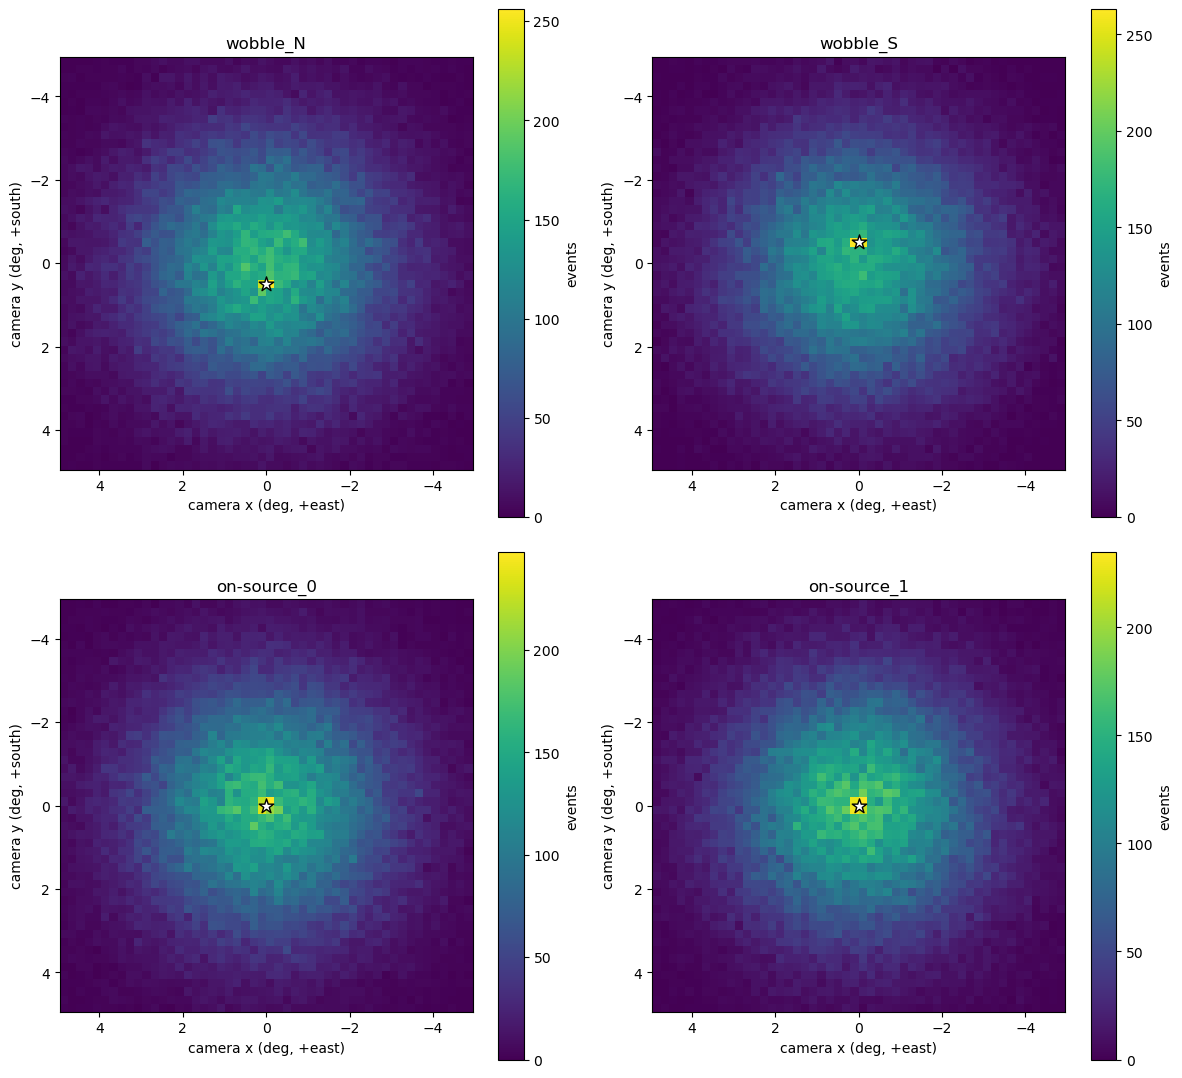

In [23]:
fig, axs = plt.subplots(2, 2, figsize=(12, 11))
for ax, (dataset, run) in zip(axs.flat, [(dataset, run) for dataset, p in pointings.items() for run in p]):
    directions = data[dataset][0]
    d = directions[directions.Run == run]
    h = ax.hist2d(d.Xoffset, d.Yoffset, bins=50, range=[CAMERA_EXTENT[:2], CAMERA_EXTENT[2:]], cmap="viridis")
    ax.scatter(*sg.make_wcs(pointings[dataset][run]).wcs_world2pix(SOURCE.ra.deg, SOURCE.dec.deg, 1), marker="*", facecolor="white", edgecolor="k", s=120)
    ax.set_xlim(CAMERA_HALF_WIDTH, -CAMERA_HALF_WIDTH)
    ax.set_ylim(CAMERA_HALF_WIDTH, -CAMERA_HALF_WIDTH)
    ax.set_aspect("equal")
    ax.set(xlabel="camera x (deg, +east)", ylabel="camera y (deg, +south)", title=run)
    fig.colorbar(h[3], ax=ax, label="events")
plt.tight_layout()

In the wobble N run the source sits 0.5 deg south of the camera center, in the wobble S run 0.5 deg north; in the on-source runs it's at the center.

## Off Regions

Both methods take the on region center in camera coordinates and return off region centers:
- `make_reflected_regions()`: the on region rotated about the **camera center** (the pointing), at the same offset $r$, as many
  as fit around the circle without overlapping. Every off region has the on region's offset from the pointing.
- `make_off_regions()` (`"ring"`, the ring background method): a ring of regions around the **on region**, $4\theta$ from it, $2\theta$ apart. It doesn't depend
  on where the pointing is.

For a source 0.5 deg south of the camera center (the wobble N run):

In [24]:
reflected = sg.make_reflected_regions(0, 0.5, THETA)
ring = sg.make_off_regions(0, 0.5, THETA)
print(f"reflected regions: {len(reflected)} off regions, alpha = {sg.calc_alpha(reflected, THETA):.3f}")
print(f"ring background: {len(ring)} off regions, alpha = {sg.calc_alpha(ring, THETA):.3f}")

reflected regions: 6 off regions, alpha = 0.167
ring background: 12 off regions, alpha = 0.083


$\alpha$ (`calc_alpha()`) is the on region's area over the total off region area, i.e. 1 / (number of off regions).

With the source at the camera center (on-source run), there is no circle to rotate the on region around, so there are no reflected regions:

In [25]:
print(f"reflected regions: {len(sg.make_reflected_regions(0, 0, THETA))} off regions")
print(f"ring background: {len(sg.make_off_regions(0, 0, THETA))} off regions")

reflected regions: 0 off regions
ring background: 12 off regions


## Counting

`OnOffCounter` does the counting for a test position (RA, DEC), run by run, in each run's own camera frame:
1. the test position is converted to the run's camera coordinates, using that run's pointing: that's the on region center
2. the off regions are placed around it (`off_method`, as above), keeping only those entirely inside the run's camera
   (`off_regions()`); if the on region itself isn't, the run gets no off regions
3. on = events whose direction is within `THETA` of the on region center, off = the same for every off region

Then the runs are added up (`combine_on_off()`): $N_{on}$ and $N_{off}$ summed, and $\alpha$ (from the off regions kept) averaged weighted by each run's $N_{off}$.
Runs with no off regions are left out, **including their on events**.

We make one counter per set of runs and method (no max distance cut, since toy events have no real images):

In [26]:
METHODS = ["reflected", "ring"]
LABELS = {"reflected": "reflected regions", "ring": "ring background"} # for plots and printouts
counters = {
    (dataset, method): sg.OnOffCounter(directions, array, pointings[dataset], THETA, None, off_method=method)
    for dataset, (directions, array) in data.items() for method in METHODS
}

Some plotting helpers. `plot_camera_regions()` redoes one run's counting with `OnOffCounter`'s pieces, to draw it
in the map frame: the test position in the run's camera frame (`to_camera()`), its off regions (`off_regions()`: the method's regions entirely inside the camera),
and the events in each region (`in_region()`). `plot_test_position()` draws it for both wobble runs and one on-source run (both
look the same), for both methods, and `print_counts()` prints the combined counts, with the excess $N_{on} - \alpha N_{off}$.

In [27]:
map_wcs = sg.make_wcs(MAP_CENTER) # map frame: deg from MAP_CENTER, +x east, +y south, like a camera frame
MAP_HALF_WIDTH = CAMERA_HALF_WIDTH + WOBBLE # every run's whole camera


def plot_camera_regions(ax, counter, run, ra, dec):
    rc = counter.counters[run] # this run's RegionCounter
    x_on, y_on = rc.to_camera(ra, dec)
    off_regions = counter.off_regions(x_on, y_on) # the method's regions entirely inside the camera
    on_inside = sg.in_camera(x_on, y_on, THETA)
    dropped = [r for r in counter.make_off_regions(x_on, y_on, THETA) if not (on_inside and sg.in_camera(*r, THETA))]
    N_on = len(rc.in_region(x_on, y_on))
    N_off = sum(len(rc.in_region(*region)) for region in off_regions)
    alpha = sg.calc_alpha(off_regions, THETA)

    def to_map(x, y):
        """This run's camera (x, y) -> the map frame."""
        return map_wcs.wcs_world2pix(*rc.w.wcs_pix2world(x, y, 1), 1)

    # event counts and regions, drawn in the map frame
    counts, _, _ = np.histogram2d(*to_map(rc.x, rc.y), bins=64, range=[[-MAP_HALF_WIDTH, MAP_HALF_WIDTH]]*2)
    ax.imshow(counts.T, origin="lower", extent=[-MAP_HALF_WIDTH, MAP_HALF_WIDTH]*2, cmap="Greys", vmin=0, vmax=1.5*counts.max())
    edge = np.linspace(-CAMERA_HALF_WIDTH, CAMERA_HALF_WIDTH, 50)
    side = np.full_like(edge, CAMERA_HALF_WIDTH)
    ax.plot(*to_map(np.r_[edge, side, edge[::-1], -side], np.r_[-side, edge, side, edge[::-1]]), color="k", lw=0.8, ls="--") # this run's camera edge
    for region in off_regions:
        ax.add_patch(Circle(to_map(*region), THETA, fill=False, color="tab:blue", lw=1))
    for region in dropped:
        ax.add_patch(Circle(to_map(*region), THETA, fill=False, color="grey", lw=1, ls=":"))
    ax.add_patch(Circle(to_map(x_on, y_on), THETA, fill=False, color="magenta", lw=1.5))
    ax.scatter(*to_map(0, 0), marker="+", color="k", s=100) # this run's pointing (camera center)
    ax.scatter(*map_wcs.wcs_world2pix(SOURCE.ra.deg, SOURCE.dec.deg, 1), marker="*", facecolor="white", edgecolor="k", s=120)

    ax.set_xlim(MAP_HALF_WIDTH, -MAP_HALF_WIDTH) # +x is east and +y south: reversed for east left, north up
    ax.set_ylim(MAP_HALF_WIDTH, -MAP_HALF_WIDTH)
    ax.set(xlabel="x from map center (deg, +east)", ylabel="y from map center (deg, +south)")
    if not on_inside:
        title = f"{run}: on region not inside the camera -> run dropped"
    elif alpha == 0:
        title = f"{run}: on {N_on}, no off regions -> run dropped"
    else:
        title = f"{run}: on {N_on}, off {N_off}, $\\alpha$ = {alpha:.3f}, excess {N_on - alpha*N_off:.1f}"
        if dropped:
            title += f"\n{len(dropped)} of {len(off_regions) + len(dropped)} off regions outside the camera, not used"
    ax.set_title(title, fontsize=9)


def plot_test_position(p, title):
    runs = [("wobble", run) for run in pointings["wobble"]] + [("on-source", "on-source_0")]
    fig, axs = plt.subplots(2, len(runs), figsize=(4*len(runs), 8.8))
    for row, method in zip(axs, METHODS):
        for ax, (dataset, run) in zip(row, runs):
            plot_camera_regions(ax, counters[dataset, method], run, p.ra.deg, p.dec.deg)
        row[0].annotate(LABELS[method], xy=(-0.35, 0.5), xycoords="axes fraction", rotation=90, va="center", fontsize=14, weight="bold")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def print_counts(p):
    for (dataset, method), counter in counters.items():
        N_on, N_off, alpha = counter.count(p.ra.deg, p.dec.deg)
        excess = N_on - alpha*N_off
        print(f"{dataset:9s} {LABELS[method]:17s}: N_on = {N_on:5d}, N_off = {N_off:5d}, alpha = {alpha:.3f}, excess = {excess:7.1f}, significance = {sg.significance(N_on, N_off, alpha):5.1f}")

## At the Source

Rows correspond to background method. Columns correspond to different runs with different data and different counts maps. Within a column, on counts should be identical between background methods, since the on source is in the same position on the same counts map for both methods.

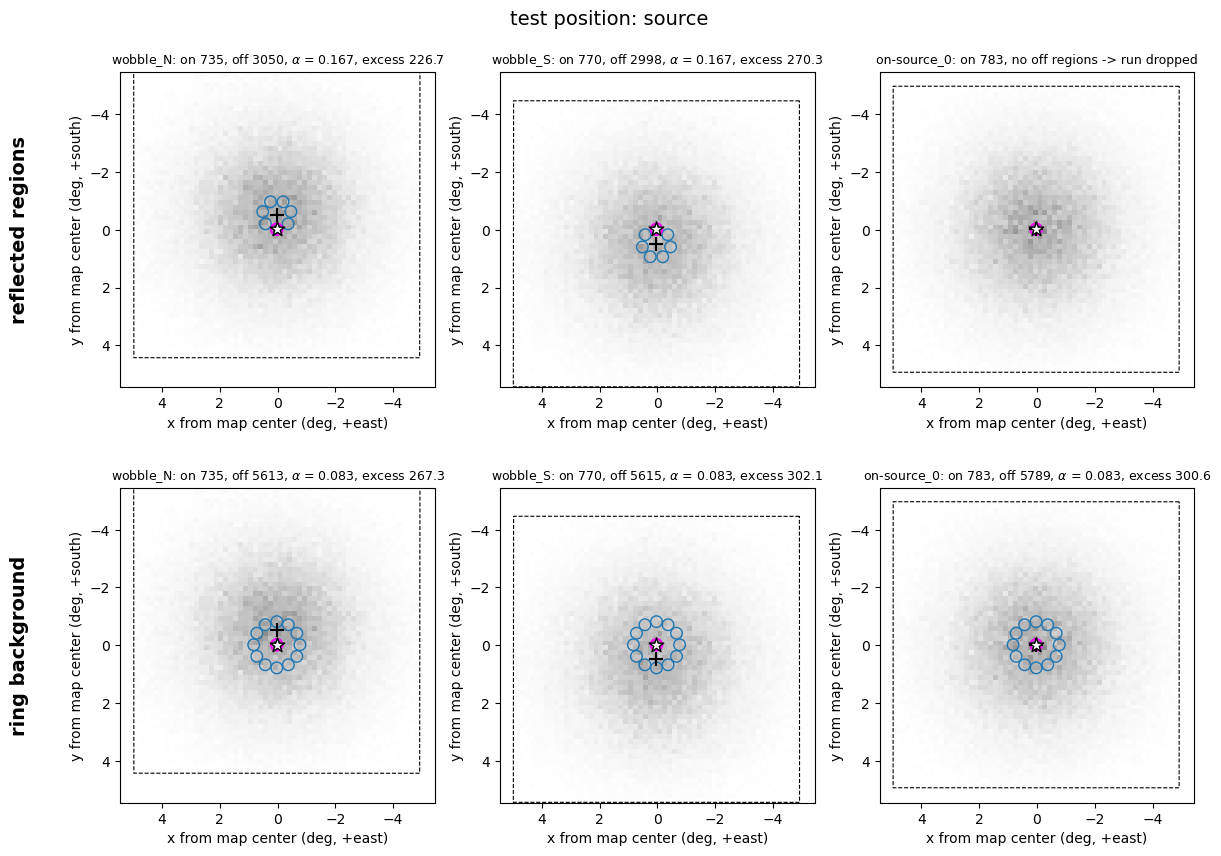

In [28]:
plot_test_position(SOURCE, "test position: source")

- **reflected regions, wobble**: the source is 0.5 deg from each pointing, so its off regions go around a 0.5 deg circle about that run's pointing.
  Each run's circle is somewhere else on the sky, but they all pass through the source.
- **reflected regions, on-source**: the source is at the camera center, so there are no off regions and every run is dropped.
- **ring background method**: the same ring of off regions around the source for every run, wobble or not. Its off regions are at other offsets from the camera
  center than the on region, and $\alpha$ only accounts for area, not for the acceptance changing with offset.

`per_run()` gives each run's numbers, and `count()` the combined ones:

In [29]:
counters["wobble", "reflected"].per_run(SOURCE.ra.deg, SOURCE.dec.deg)

,Date,Run,on,off,alpha
0,toy,wobble_N,735,3050,0.166667
1,toy,wobble_S,770,2998,0.166667


In [30]:
counters["on-source", "reflected"].per_run(SOURCE.ra.deg, SOURCE.dec.deg)

,Date,Run,on,off,alpha
0,toy,on-source_0,783,0,0.0
1,toy,on-source_1,767,0,0.0


In [31]:
print_counts(SOURCE)

wobble    reflected regions: N_on =  1505, N_off =  6048, alpha = 0.167, excess =   497.0, significance =  13.4
wobble    ring background  : N_on =  1505, N_off = 11228, alpha = 0.083, excess =   569.3, significance =  16.3
on-source reflected regions: N_on =     0, N_off =     0, alpha = 0.000, excess =     0.0, significance =   0.0
on-source ring background  : N_on =  1550, N_off = 11426, alpha = 0.083, excess =   597.8, significance =  16.9


## Other Test Positions

Any other test position is counted the same way. With wobble runs, it is now a different distance from each run's pointing,
so each run gets its own reflected circle, number of off regions and $\alpha$.

The test positions below are given as offsets from the map center (`MAP_CENTER`). Each is one sky position for every run, so
the on regions cover the same sky and their on counts can be compared directly.

In [32]:
def offset(east, north):
    """The sky position east, north (deg) of the map center."""
    return MAP_CENTER.spherical_offsets_by(east*u.deg, north*u.deg)

### 1.5 deg N of the Map Center

The on region is about 1.5 deg N of the on-source pointing, but 1 deg N of the wobble N pointing and 2 deg N of the wobble S pointing, so their reflected circles differ in size. The ring background method's off regions are the same for every run.

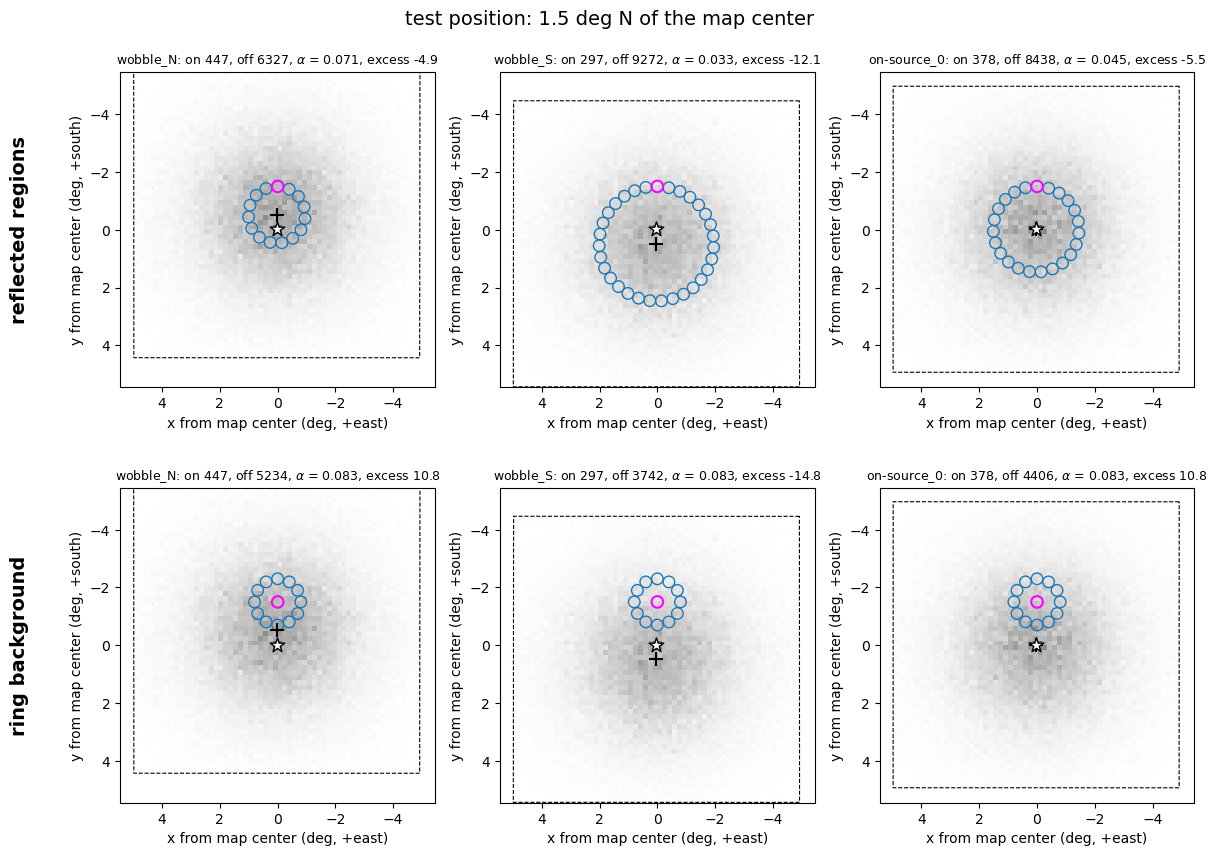

wobble    reflected regions: N_on =   744, N_off = 15599, alpha = 0.049, excess =   -17.0, significance =  -0.6
wobble    ring background  : N_on =   744, N_off =  8976, alpha = 0.083, excess =    -4.0, significance =  -0.1
on-source reflected regions: N_on =   730, N_off = 17018, alpha = 0.045, excess =   -43.5, significance =  -1.5
on-source ring background  : N_on =   730, N_off =  8758, alpha = 0.083, excess =     0.2, significance =   0.0


In [33]:
p = offset(0, 1.5)
plot_test_position(p, "test position: 1.5 deg N of the map center")
print_counts(p)

### On a Wobble Pointing

The test position is the wobble N run's camera center: with reflected regions that run is dropped, like the on-source runs at the
source. The other runs still count it.

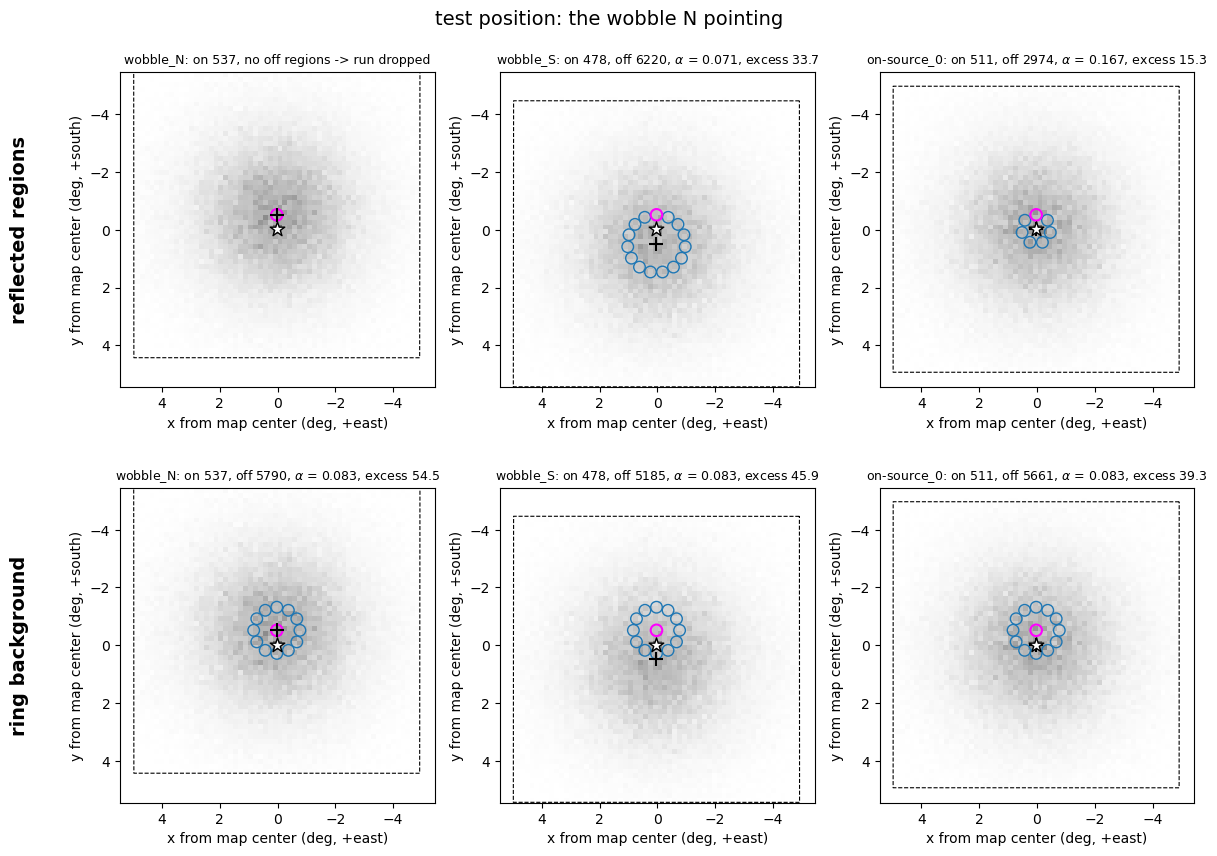

wobble    reflected regions: N_on =   478, N_off =  6220, alpha = 0.071, excess =    33.7, significance =   1.5
wobble    ring background  : N_on =  1015, N_off = 10975, alpha = 0.083, excess =   100.4, significance =   3.1
on-source reflected regions: N_on =   992, N_off =  6081, alpha = 0.167, excess =   -21.5, significance =  -0.6
on-source ring background  : N_on =   992, N_off = 11313, alpha = 0.083, excess =    49.3, significance =   1.5


In [34]:
p = pointings["wobble"]["wobble_N"]
plot_test_position(p, "test position: the wobble N pointing")
print_counts(p)

### Next to the Source

Here we pick the test position one reflected step around the wobble N run's circle from the source, so that one of its off regions
lands on the source. The source's events then count as background (the blue circle on the star in the wobble N panel): nothing
keeps known sources out of the off regions.

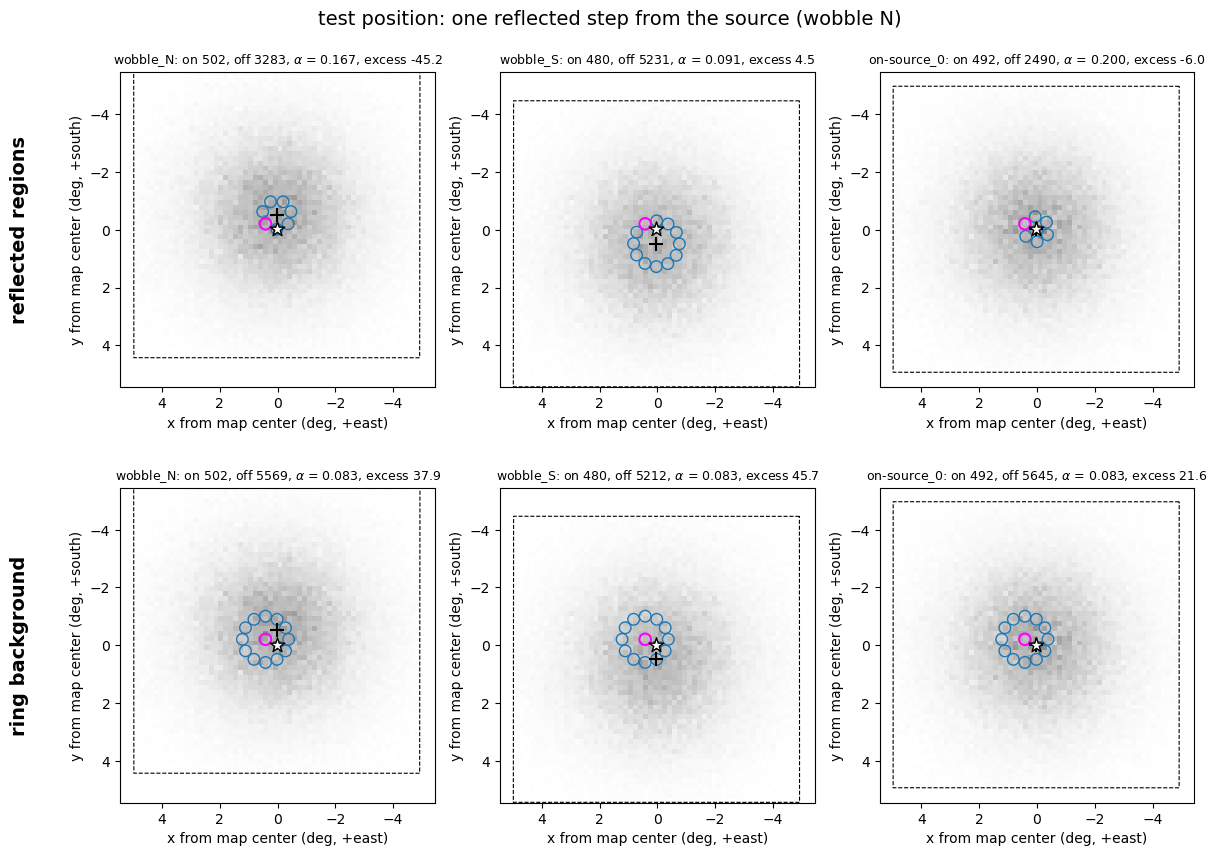

wobble    reflected regions: N_on =   982, N_off =  8514, alpha = 0.120, excess =   -40.7, significance =  -1.2
wobble    ring background  : N_on =   982, N_off = 10781, alpha = 0.083, excess =    83.6, significance =   2.6
on-source reflected regions: N_on =   987, N_off =  5071, alpha = 0.200, excess =   -27.2, significance =  -0.8
on-source ring background  : N_on =   987, N_off = 11173, alpha = 0.083, excess =    55.9, significance =   1.7


In [35]:
# rotate the source about the wobble N pointing by one reflected step, in that run's camera frame
w_N = sg.make_wcs(pointings["wobble"]["wobble_N"])
x_s, y_s = w_N.wcs_world2pix(SOURCE.ra.deg, SOURCE.dec.deg, 1)
step = 2*np.pi / (len(sg.make_reflected_regions(x_s, y_s, THETA)) + 1)
x, y = x_s*np.cos(step) + y_s*np.sin(step), -x_s*np.sin(step) + y_s*np.cos(step)
ra, dec = w_N.wcs_pix2world(x, y, 1)
p = SkyCoord(ra*u.deg, dec*u.deg)

plot_test_position(p, "test position: one reflected step from the source (wobble N)")
print_counts(p)

### Camera Edge

The ring background method's off regions start to leave the camera. Only the ones entirely inside the camera are counted, and only
they make up $\alpha$ (dotted: not used; titles count them). The ones left are on the camera-center side of the on region, where
the acceptance is higher, so here the ring background method overestimates the background and gives a negative excess.

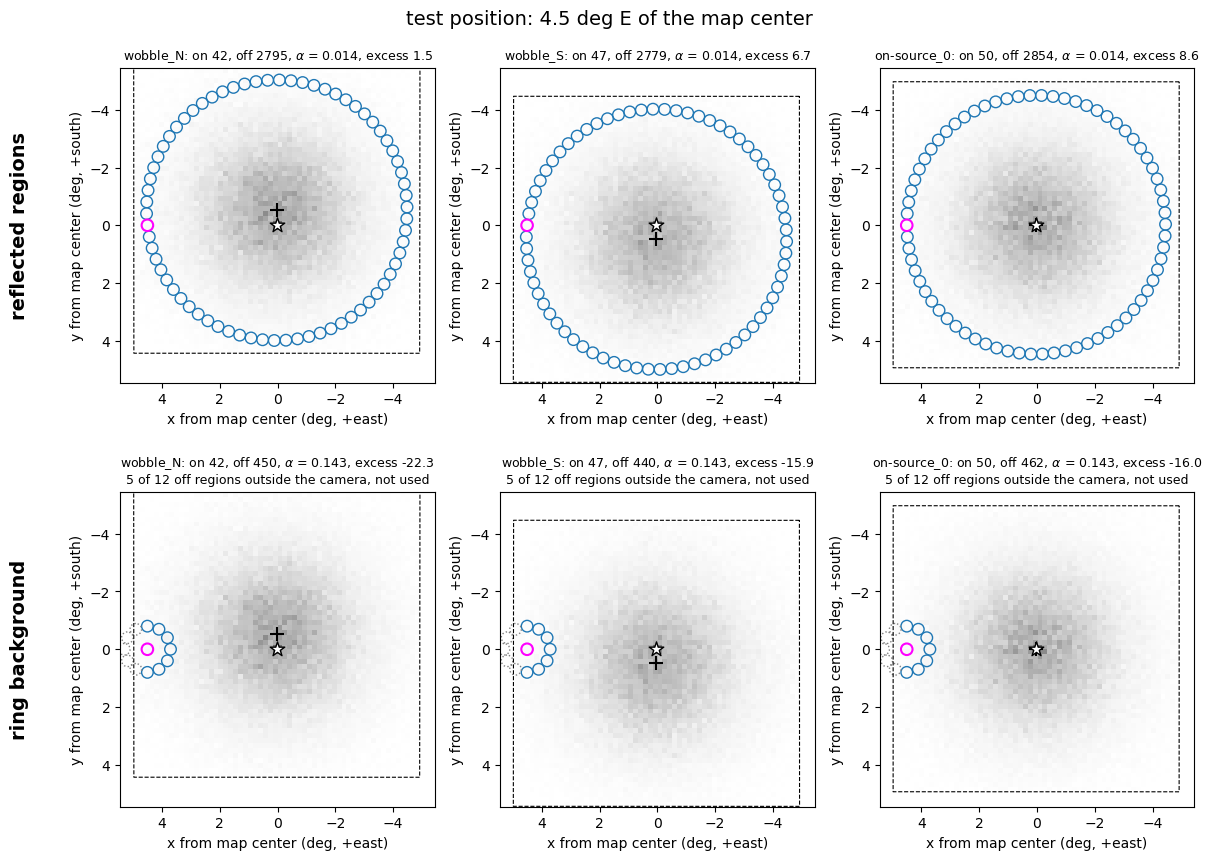

wobble    reflected regions: N_on =    89, N_off =  5574, alpha = 0.014, excess =     8.2, significance =   0.9
wobble    ring background  : N_on =    89, N_off =   890, alpha = 0.143, excess =   -38.1, significance =  -3.4
on-source reflected regions: N_on =    93, N_off =  5759, alpha = 0.014, excess =     9.5, significance =   1.0
on-source ring background  : N_on =    93, N_off =   943, alpha = 0.143, excess =   -41.7, significance =  -3.6


In [36]:
p = offset(4.5, 0)
plot_test_position(p, "test position: 4.5 deg E of the map center")
print_counts(p)

### Toward a Corner

Reflected circles bigger than the camera's half width leave the camera too, so most of the reflected regions aren't used. The ones
left are still at the on region's offset from the pointing, and $\alpha$ comes from them alone.

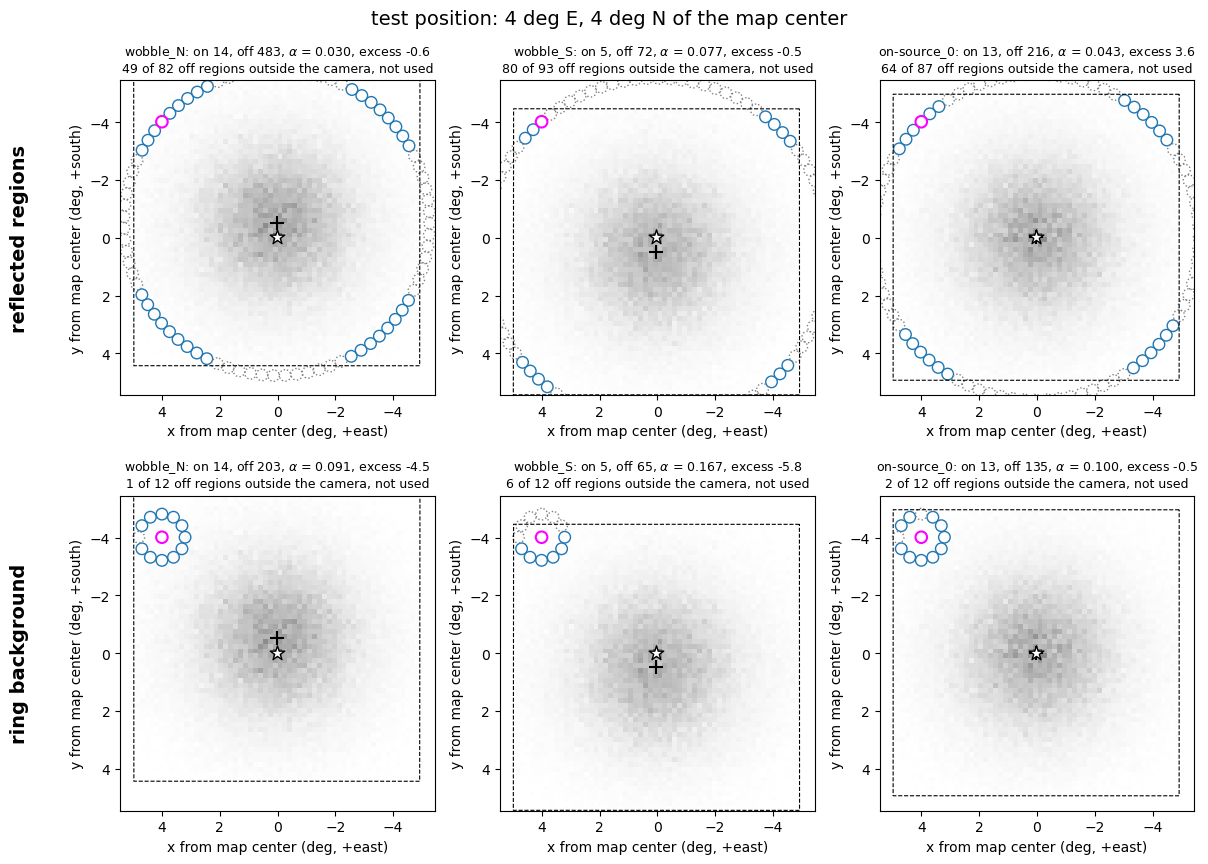

wobble    reflected regions: N_on =    19, N_off =   555, alpha = 0.036, excess =    -1.2, significance =  -0.3
wobble    ring background  : N_on =    19, N_off =   268, alpha = 0.109, excess =   -10.3, significance =  -1.9
on-source reflected regions: N_on =    23, N_off =   441, alpha = 0.043, excess =     3.8, significance =   0.8
on-source ring background  : N_on =    23, N_off =   264, alpha = 0.100, excess =    -3.4, significance =  -0.6


In [37]:
p = offset(4, 4)
plot_test_position(p, "test position: 4 deg E, 4 deg N of the map center")
print_counts(p)

## Sky Map

The same map as `analysis_tools/pff_analysis.ipynb` (`calc_sigmap()` + `plot_sky_map()`, same extent and bins): every bin center
is a test position, counted exactly as above, run by run. Each map combines its set's runs:
- **wobble**: wobble_N and wobble_S are each counted in their own camera frame, then their $N_{on}$ and $N_{off}$ are summed
  (and $\alpha$ weighted by each run's $N_{off}$) into one map
- **on-source**: on-source_0 and on-source_1 are combined the same way

White `x`: the wobble pointings. Note:
- the darker ring around the source in the wobble reflected regions map: test positions on a run's reflected circle through the source,
  whose off regions land on it (see "Next to the Source")
- no source in the on-source reflected regions map: test positions within `THETA` of the pointing (here, the source) have every run dropped
- the broad positive area around the source for the ring background method, from the acceptance (see "On a Wobble Pointing")

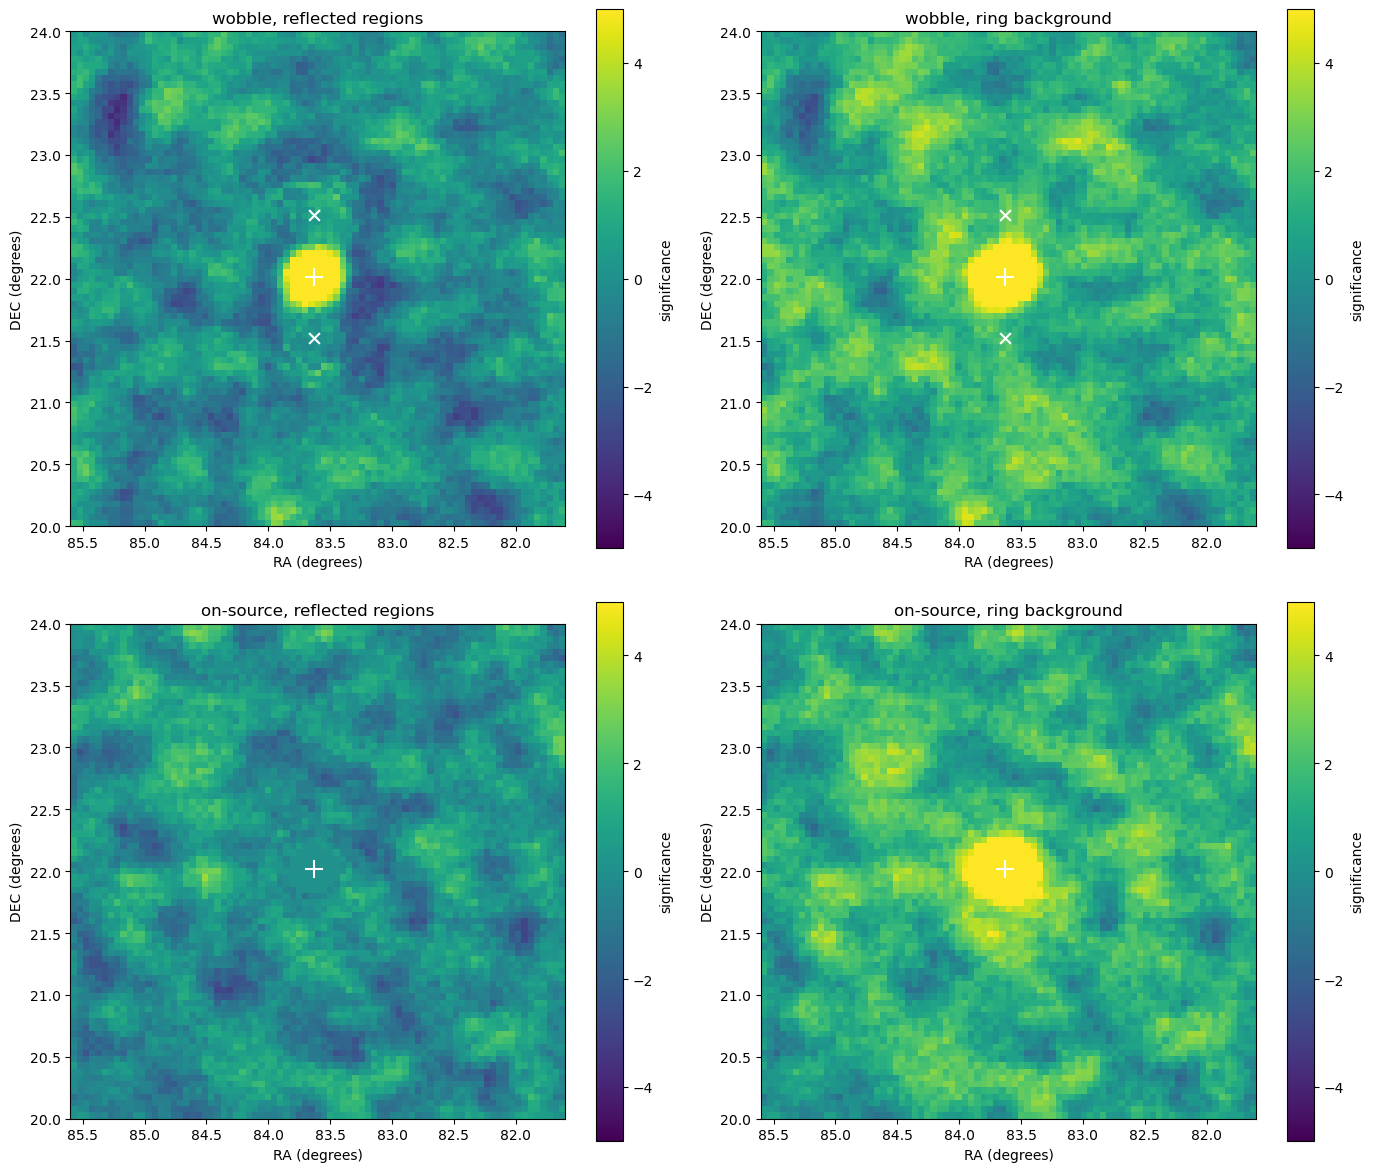

In [38]:
PLOT_RADIUS = 2 # deg from the map center
BIN_WIDTH = 0.05

n_bins = int(2*PLOT_RADIUS / BIN_WIDTH)
bins_RA = np.linspace(MAP_CENTER.ra.deg - PLOT_RADIUS, MAP_CENTER.ra.deg + PLOT_RADIUS, n_bins)
bins_DEC = np.linspace(MAP_CENTER.dec.deg - PLOT_RADIUS, MAP_CENTER.dec.deg + PLOT_RADIUS, n_bins)

fig, axs = plt.subplots(2, 2, figsize=(14, 12))
for ax, (dataset, method) in zip(axs.flat, counters):
    sig = sg.calc_sigmap(counters[dataset, method], bins_RA, bins_DEC, BIN_WIDTH)
    sg.plot_sky_map(ax, sig, sig.significance, "significance", bins_RA, bins_DEC, on_region=(SOURCE.ra.deg, SOURCE.dec.deg), vmin=-5, vmax=5)
    if dataset == "wobble":
        for pointing in pointings[dataset].values():
            ax.scatter(pointing.ra.deg, pointing.dec.deg, marker="x", color="white", s=60)
    ax.set_title(f"{dataset}, {LABELS[method]}")
plt.tight_layout()

## Summary

- **reflected regions**: off regions at the on region's offset from each run's pointing, so they share its acceptance. Needs the test
  position away from the pointing: runs with the test position within `THETA` of their pointing are dropped, so on-source runs
  can't measure the source.
- **ring background method**: off regions around the test position, the same for any pointing, so it works for on-source runs. But they sit at
  other camera offsets, and $\alpha$ only accounts for area.
- **both**: only off regions entirely inside the camera are counted and make up $\alpha$, and off regions can land on the source.